In [1]:
import core
import rasterio
from rasterio.plot import show

In [2]:
filename = "./assets/rst/clippedDem_12N.tif"
rasterObj = core.getRasterObject(filename)

In [3]:
core.describeRaster(rasterObj)

Profile: 
 {'driver': 'GTiff', 'dtype': 'int16', 'nodata': -9999.0, 'width': 544, 'height': 535, 'count': 1, 'crs': CRS.from_wkt('PROJCS["NAD27 / UTM zone 12N",GEOGCS["NAD27",DATUM["North_American_Datum_1927",SPHEROID["Clarke 1866",6378206.4,294.978698213898,AUTHORITY["EPSG","7008"]],AUTHORITY["EPSG","6267"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4267"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26712"]]'), 'transform': Affine(25.65010730167443, 0.0, 574306.4323383475,
       0.0, -30.922000999722275, 3728996.5502193), 'blockxsize': 544, 'blockysize': 7, 'tiled': False, 'interleave': 'band'}
Shape: 
 (535, 544)
Size (in pixels): 
 291040
Number 

In [4]:
elevationArray = rasterObj.read(1)
core.describe_elevation(elevationArray)

Elevation Array: 
 [[1475 1470 1467 ... 1809 1809 1808]
 [1469 1464 1460 ... 1816 1816 1816]
 [1461 1458 1453 ... 1815 1819 1820]
 ...
 [1618 1616 1616 ... 1752 1753 1754]
 [1621 1617 1617 ... 1743 1745 1749]
 [1621 1617 1617 ... 1739 1740 1743]]
Shape: 
 (535, 544)
Data Type: 
 int16
No. of NoData Values: 
 0
Min Value: 
 1339
Max Value: 
 2056
Mean Value: 
 1689.870419873557
Std Value: 
 113.87570895303827


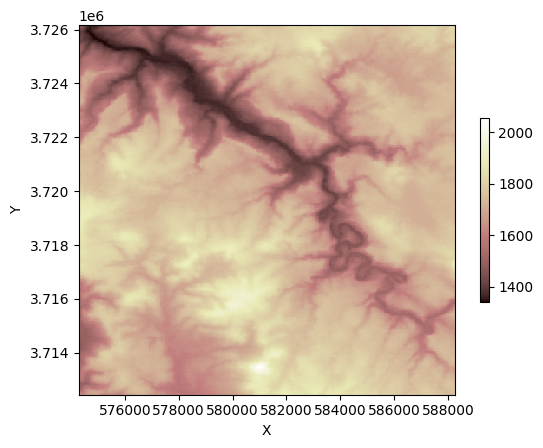

In [5]:
mg = core.CreateGridFromDEM(rasterObj, add_elev=True)

In [6]:
import matplotlib.pyplot as plt

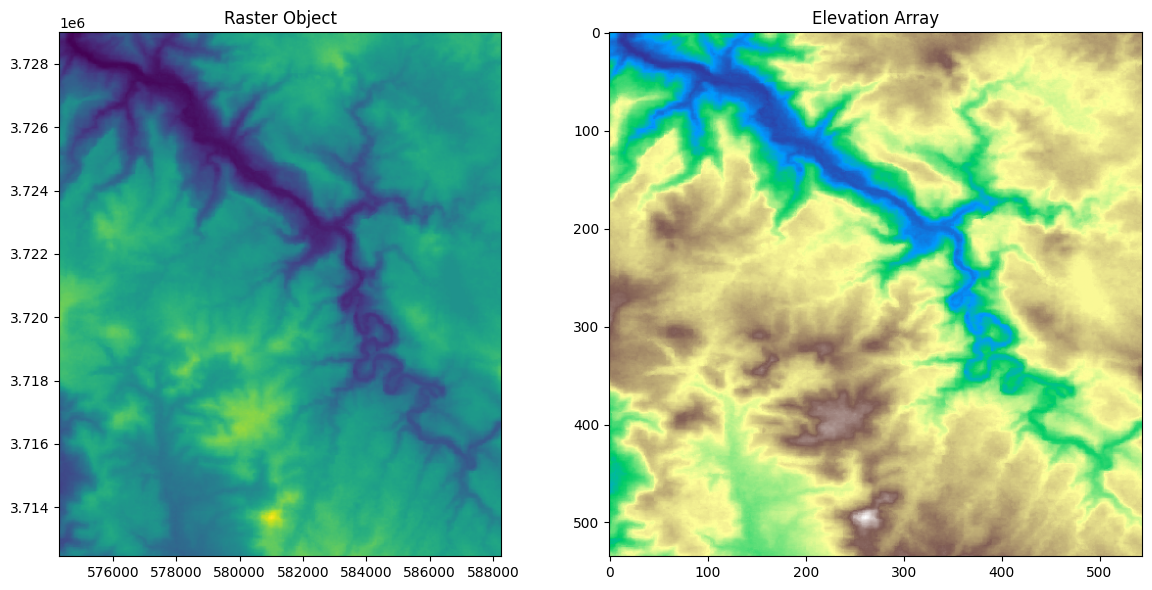

In [7]:
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns, figure size (width, height) in inches

# Plot the raster object in the first subplot
show(rasterObj, ax=axes[0])
axes[0].set_title("Raster Object")

# Read the elevation array and describe it
elevArr = rasterObj.read(1)  # <class 'numpy.ndarray'>

# Plot the elevation array in the second subplot
show(elevArr, ax=axes[1], cmap="terrain")
axes[1].set_title("Elevation Array")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [8]:
from landlab.components.overland_flow import OverlandFlow
import numpy as np

#set and apply and initial height

initialHeight = 3
depthArray = np.ones(elevationArray.shape)*initialHeight
mg.at_node["surface_water__depth"] = depthArray
#define the flood objeds
of = OverlandFlow(mg, steep_slopes=True)

In [9]:
#list to store times
dtList = []
#Run once and store elapsed time
of.run_one_step(dt= 1)
dtList.append(of.dt)
print(of.dt)

1.0


In [10]:
# explore the output data and location

# model outputs
print(of.output_var_names)

# where this nodes are locates
print(of.var_loc("surface_water__depth"))

# show the water depth array
print(mg.at_node["surface_water__depth"])
('surface_water__depth', 'surface_water__discharge', 'water_surface__gradient')



('surface_water__depth', 'surface_water__discharge', 'water_surface__gradient')
node
[3.00001 3.00001 3.00001 ... 3.00001 3.00001 3.00001]


('surface_water__depth', 'surface_water__discharge', 'water_surface__gradient')

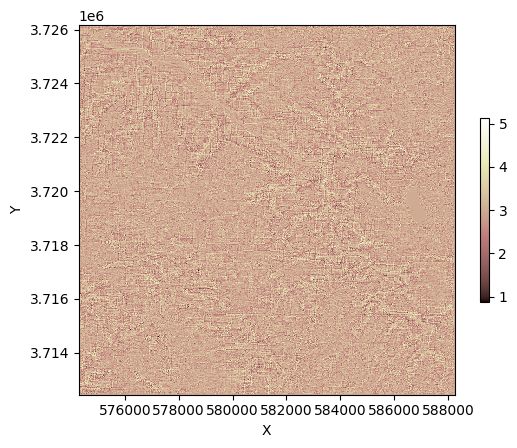

In [11]:
from landlab import RasterModelGrid, imshow_grid
# plot the resulting water depth for the first run
imshow_grid(mg, "surface_water__depth", shrink=0.5)


In [12]:
# run the model for 100 time steps
for i in range(100):
    of.run_one_step()
    dtList.append(of.dt)
    print("Time step: %.2f seconds. Elapsed time %.2f seconds"%(of.dt,sum(dtList)))

Time step: 2.53 seconds. Elapsed time 3.53 seconds
Time step: 2.07 seconds. Elapsed time 5.59 seconds
Time step: 1.72 seconds. Elapsed time 7.31 seconds
Time step: 1.50 seconds. Elapsed time 8.81 seconds
Time step: 1.40 seconds. Elapsed time 10.21 seconds
Time step: 1.36 seconds. Elapsed time 11.57 seconds
Time step: 1.33 seconds. Elapsed time 12.90 seconds
Time step: 1.29 seconds. Elapsed time 14.19 seconds
Time step: 1.25 seconds. Elapsed time 15.44 seconds
Time step: 1.20 seconds. Elapsed time 16.65 seconds
Time step: 1.17 seconds. Elapsed time 17.82 seconds
Time step: 1.15 seconds. Elapsed time 18.96 seconds
Time step: 1.12 seconds. Elapsed time 20.09 seconds
Time step: 1.11 seconds. Elapsed time 21.20 seconds
Time step: 1.10 seconds. Elapsed time 22.30 seconds
Time step: 1.10 seconds. Elapsed time 23.40 seconds
Time step: 1.08 seconds. Elapsed time 24.49 seconds
Time step: 1.07 seconds. Elapsed time 25.56 seconds
Time step: 1.06 seconds. Elapsed time 26.62 seconds
Time step: 1.05 

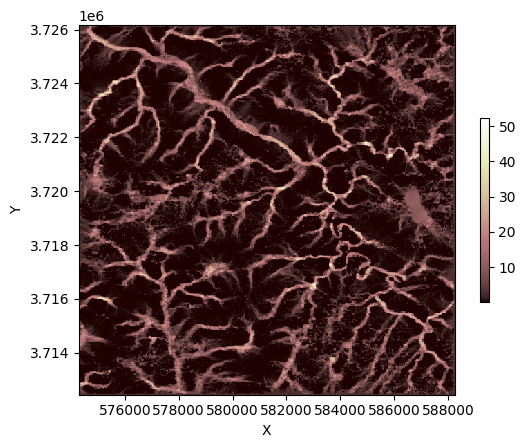

In [13]:
# plot the resulting water depth for the 101th run
imshow_grid(mg, "surface_water__depth", shrink=0.5)

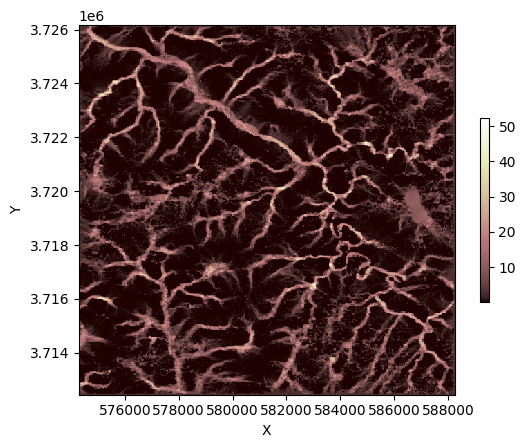

In [34]:
imshow_grid(mg, "surface_water__depth", shrink=0.5)

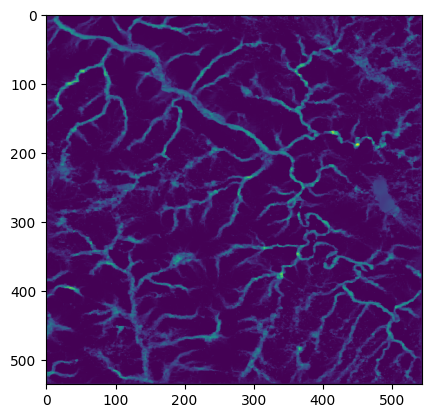

In [15]:
from matplotlib import pyplot as plt

#convert the resulting data to a numpy array
zArray = mg.at_node["surface_water__depth"].reshape(rasterObj.shape)[::-1,:]
#plot the array
plt.imshow(zArray)

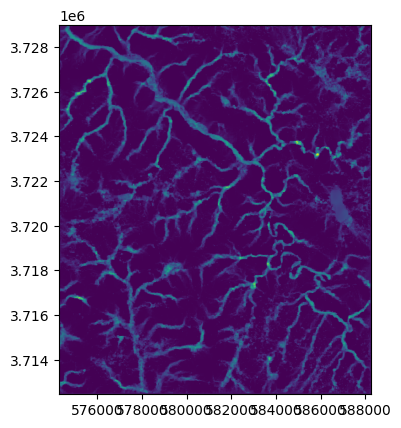

<Axes: >

In [16]:
# Write the array to a new GeoTIFF file
with rasterio.open(
        './Out/floodSurfaceDepth.tif',
        'w',
        driver='GTiff',
        height=rasterObj.height,
        width=rasterObj.width,
        count=1,  # number of bands
        dtype=zArray.dtype,
        crs=rasterObj.crs,
        transform=rasterObj.transform
) as dst:
    dst.write(zArray, 1)  # write the data to the first band
# Show the resulting raster
floodObj = rasterio.open('./Out/floodSurfaceDepth.tif')
show(floodObj)

To be checked

In [17]:
# import rasterio
# from landlab.io import read_esri_ascii
# from landlab import RasterModelGrid
# import numpy as np

# with rasterio.open('./Out/floodSurfaceDepth.tif') as src:
#     dem_data = src.read(1, masked=True)
#     transform = src.transform
#     dx = transform[0]

# # Crear el grid de Landlab
# nrows, ncols = dem_data.shape
# mg = RasterModelGrid((nrows, ncols), dx)
# z = mg.add_field("topographic__elevation", dem_data.filled(np.nan), at="node")

# from landlab.components import DepressionFinderAndRouter

# # Rellenar depresiones
# z[np.isnan(z)] = z[~np.isnan(z)].min()  # Evitar nodos NaN para procesamiento
# depr_finder = DepressionFinderAndRouter(mg)
# depr_finder.map_depressions()

# from landlab.components import FlowAccumulator

# fa = FlowAccumulator(mg)
# fa.run_one_step()


In [18]:
# from landlab.components import BasinMapper

# # Necesitas definir puntos de salida (outlet) para cada cuenca
# # Por ejemplo, nodo más bajo o más a la derecha:
# outlet_nodes = [mg.node_at_cell_center[-1]]  # ejemplo sencillo

# bm = BasinMapper(mg, outlets=outlet_nodes)
# bm.map_basins()

# # Resultado: campo 'basin__id' con ID por cada cuenca
# basins = mg.at_node['basin__id']


In [19]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8, 6))
# imshow = mg.plot_var('basin__id', cmap='tab20')
# plt.colorbar(imshow, label='ID de Cuenca')
# plt.title("Delimitación de Cuencas con Landlab")
# plt.show()


Empezando de aquí se usa 

https://gidahatari.com/ih-es/delimitacion-de-redes-hidricas-a-partir-de-un-dem-raster-con-python-y-landlab-tutorial

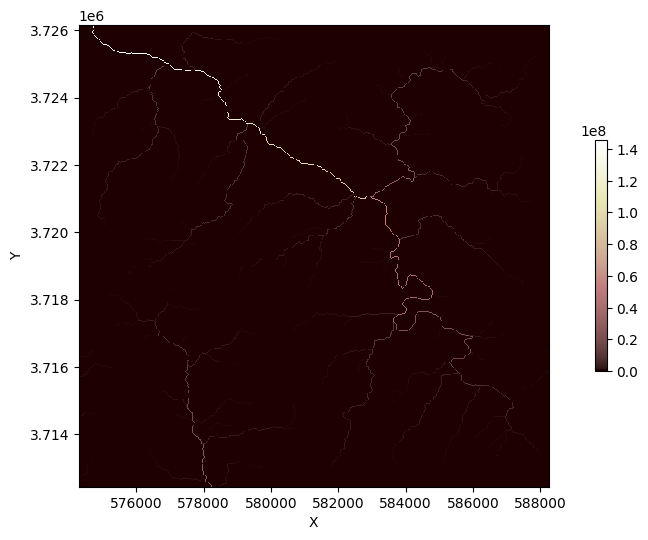

In [35]:
from landlab.components import FlowAccumulator, DepressionFinderAndRouter, ChannelProfiler
#flow direction
fa = FlowAccumulator(mg, flow_director='D4')
fa.run_one_step()

#fill sinks
df = DepressionFinderAndRouter(mg)
df.map_depressions()
#plot corrected drainage area
fig = plt.figure(figsize=(12,6))
imshow_grid(mg, 'drainage_area', shrink=0.5)

In [21]:
from shapely.geometry import LineString
import geopandas as gpd

odict_keys([np.int64(68544), np.int64(72895), np.int64(38624), np.int64(162), np.int64(153), np.int64(290511)])


,nodeStart,nodeEnd,geometry
0,68544,77272,"LINESTRING (574306.432 3715685.193, 574332.082..."
1,72895,64718,"LINESTRING (588234.441 3715864.744, 588208.79 ..."
2,38624,46246,"LINESTRING (574306.432 3714274.437, 574332.082..."
3,162,14882,"LINESTRING (578461.75 3712453.28, 578487.4 371..."
4,153,3410,"LINESTRING (578230.899 3712453.28, 578230.899 ..."
...,...,...,...
93,64113,44558,"LINESTRING (586233.732 3715454.342, 586259.382..."
94,44558,37492,"LINESTRING (586977.585 3714530.938, 586977.585..."
95,44558,40732,"LINESTRING (586977.585 3714530.938, 586951.935..."
96,37492,33135,"LINESTRING (587131.486 3714197.487, 587131.486..."


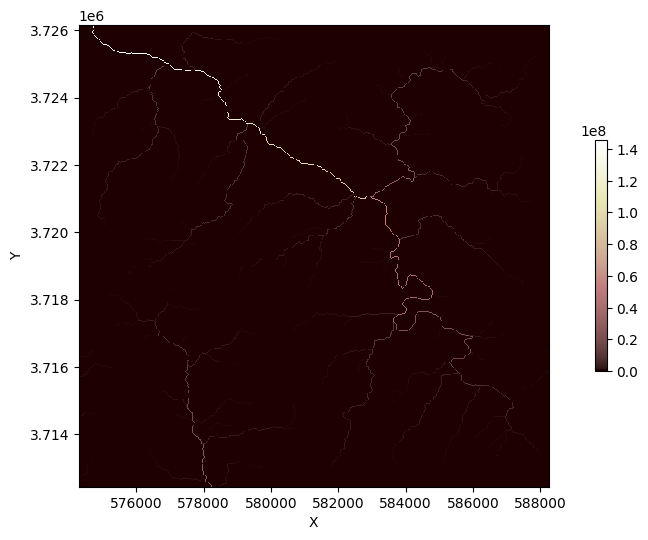

In [40]:
#profile the channel networks
profiler = ChannelProfiler(
    mg,
    number_of_watersheds=6,
    minimum_channel_threshold=1000000,
    main_channel_only=False)

#run profiler
profiler.run_one_step()

#extract profile dict
profDict = profiler.data_structure
print(profDict.keys())
#show the channel network
fig = plt.figure(figsize=(12,6))
imshow_grid(mg, 'drainage_area', shrink=0.5)

#create a geopandas dataframe to store the channel network
multiLineList = []
multiLineIndex = []

for disPoint in profDict.keys():
    segDict = profDict[disPoint]   
    for segItem in segDict.keys():   
        coordList = []      
        nodeArray = segDict[segItem]['ids']
        for node in nodeArray:
            coordList.append([mg.x_of_node[node],mg.y_of_node[node]])
        multiLine = LineString(coordList)
        multiLineList.append(multiLine)
        multiLineIndex.append(segItem)
colDict = {'nodeStart':[a[0] for a in multiLineIndex],
          'nodeEnd':[a[1] for a in multiLineIndex]}
gdf = gpd.GeoDataFrame(colDict,index=range(len(multiLineIndex)), crs='epsg:'+str(rasterObj.crs.to_epsg()), geometry=multiLineList)
#show resulting geodataframe
gdf

<Axes: >

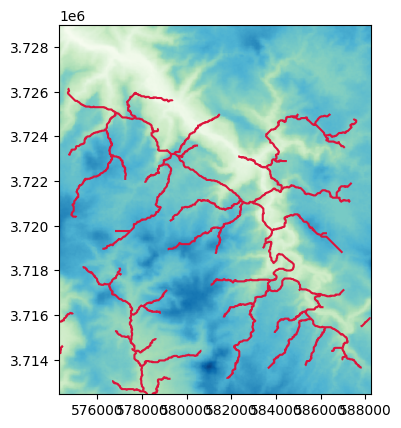

In [43]:
#plot raster with stream networks
fig,ax = plt.subplots()
show(rasterObj, ax=ax, cmap='GnBu')
gdf.plot(ax=ax, color='crimson')

<Axes: xlabel='X', ylabel='Y'>

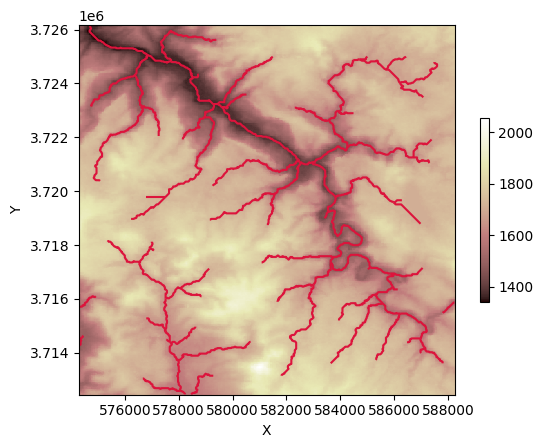

In [45]:
# #export geodataframe to shapefile
# gdf.to_file('../output/waterNetwork.shp')

#plot raster with stream networks
fig,ax = plt.subplots()
imshow_grid(mg, "topographic__elevation", shrink=0.5, at="node")
gdf.plot(ax=ax, color='crimson')

In [ ]:
core.define_basin_from_coords(mg, (3724000, 580000
                                   ))